In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [10]:
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "df_file.csv"

df = pd.read_csv(DATA_PATH)

# Remove ID column if exists
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

print("Initial Shape:", df.shape)
print(df.head())
print(df.describe())

Initial Shape: (2225, 2)
                                                Text  Label
0  Budget to set scene for election\n \n Gordon B...      0
1  Army chiefs in regiments decision\n \n Militar...      0
2  Howard denies split over ID cards\n \n Michael...      0
3  Observers to monitor UK election\n \n Minister...      0
4  Kilroy names election seat target\n \n Ex-chat...      0
             Label
count  2225.000000
mean      2.027416
std       1.438694
min       0.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       4.000000


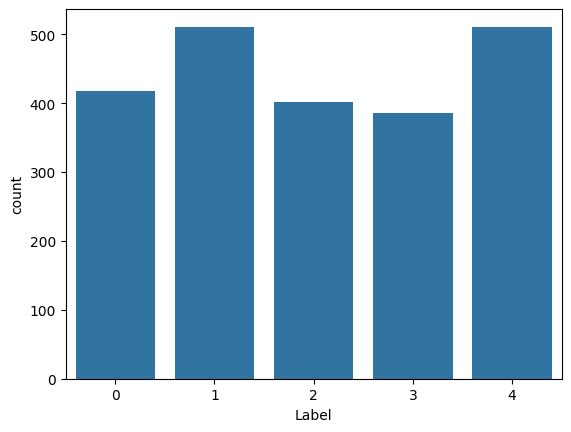

In [11]:
df["Label"].value_counts()
sns.countplot(x="Label", data=df)
plt.show()

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df["Text"] = df["Text"].apply(clean_text)

In [13]:
# Save Processed Data

processed_path = BASE_DIR / "data" / "processed" / "df_file.csv"
df.to_csv(processed_path, index=False)

print("Data preprocessing completed and saved.")

Data preprocessing completed and saved.
